1D best shift = 3.0
1D max absolute error = 0.19244725570675006
2D max absolute error = 0.34086076654623454


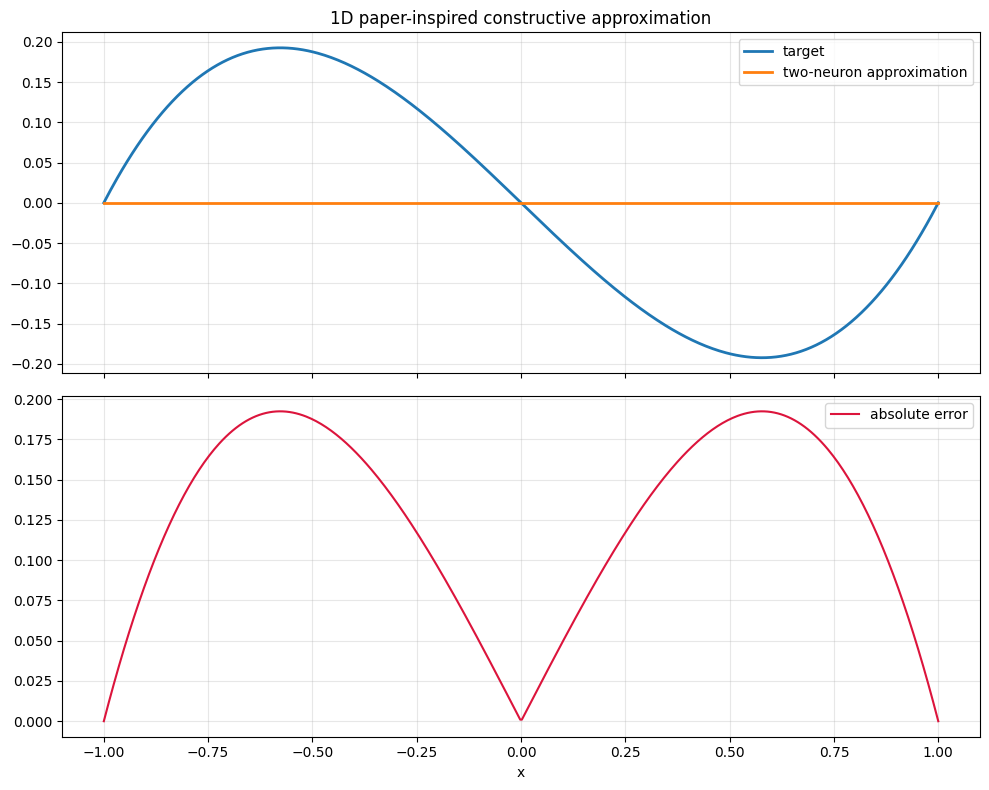

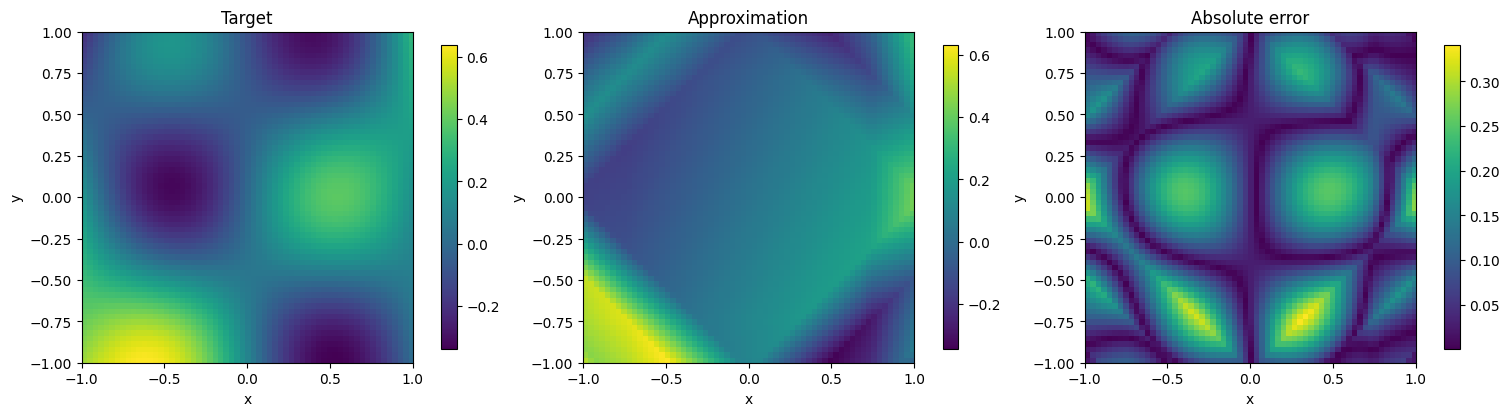

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Iterable
from numpy.polynomial import Polynomial


def paper_like_polynomials(count: int) -> list[Polynomial]:
    x = Polynomial([0.0, 1.0])
    candidates = [
        Polynomial([1.0]),
        x,
        x**2,
        x**2 - x,
        x**2 - 1.0,
        x**3,
        x**3 - x,
        x**3 - 1.0,
        x**4,
        x**4 - x,
        x**4 - 1.0,
        x**4 + x,
        x**4 + x - 1.0,
        x**5,
        x**5 - x,
    ]
    return candidates[:count]


def monotone_split(samples: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    samples = np.asarray(samples, dtype=float)
    deltas = np.diff(samples, prepend=samples[0])
    positive = np.cumsum(np.clip(deltas, 0.0, None))
    negative = np.cumsum(np.clip(-deltas, 0.0, None))

    def normalize(values: np.ndarray) -> np.ndarray:
        span = values[-1] - values[0]
        if np.abs(span) < 1e-12:
            return np.linspace(0.0, 1.0, len(values))
        return (values - values[0]) / span

    return normalize(positive), normalize(negative)


@dataclass
class PaperLikeActivation:
    polynomial_count: int = 8
    samples_per_interval: int = 128
    tail_scale: float = 1.5

    def __post_init__(self) -> None:
        self.polynomials = paper_like_polynomials(self.polynomial_count)
        self.x_table, self.y_table = self._build_lookup_table()

    def _build_lookup_table(self) -> tuple[np.ndarray, np.ndarray]:
        x_points: list[float] = []
        y_points: list[float] = []
        current_value = -0.96
        step = 1.92 / (2 * self.polynomial_count)
        local_grid = np.linspace(-1.0, 1.0, self.samples_per_interval)

        def append_interval(x_start: float, x_end: float, shape: np.ndarray) -> None:
            nonlocal current_value
            x_interval = np.linspace(x_start, x_end, self.samples_per_interval)
            y_interval = current_value + step * shape
            if x_points and np.isclose(x_interval[0], x_points[-1]):
                x_interval = x_interval[1:]
                y_interval = y_interval[1:]
            x_points.extend(x_interval.tolist())
            y_points.extend(y_interval.tolist())
            current_value = y_interval[-1]

        for index in reversed(range(self.polynomial_count)):
            polynomial = self.polynomials[index]
            sampled = polynomial(local_grid)
            _, negative_shape = monotone_split(sampled)
            append_interval(-(4 * index + 2), -(4 * index), negative_shape)

        for index, polynomial in enumerate(self.polynomials):
            sampled = polynomial(local_grid)
            positive_shape, _ = monotone_split(sampled)
            append_interval(4 * index, 4 * index + 2, positive_shape)

        return np.asarray(x_points), np.asarray(y_points)

    def __call__(self, x: np.ndarray | float) -> np.ndarray:
        values = np.asarray(x, dtype=float)
        scalar_input = values.ndim == 0
        values = np.atleast_1d(values)

        left_x = self.x_table[0]
        right_x = self.x_table[-1]
        left_y = self.y_table[0]
        right_y = self.y_table[-1]

        result = np.interp(np.clip(values, left_x, right_x), self.x_table, self.y_table)

        left_mask = values < left_x
        if np.any(left_mask):
            result[left_mask] = left_y - (left_y + 1.0) * np.exp((values[left_mask] - left_x) / self.tail_scale)

        right_mask = values > right_x
        if np.any(right_mask):
            result[right_mask] = right_y + (1.0 - right_y) * (1.0 - np.exp(-(values[right_mask] - right_x) / self.tail_scale))

        if scalar_input:
            return np.asarray(result[0])
        return result


def fit_shifted_two_neuron_model(target_fn, x_grid: np.ndarray, activation: PaperLikeActivation, shifts: Iterable[float]) -> tuple[float, float, np.ndarray, np.ndarray]:
    y = target_fn(x_grid)
    best: tuple[float, float, np.ndarray, np.ndarray] | None = None

    for shift in shifts:
        basis = np.column_stack([np.ones_like(x_grid), activation(-x_grid - shift), activation(x_grid + shift)])
        coeffs, *_ = np.linalg.lstsq(basis, y, rcond=None)
        prediction = basis @ coeffs
        max_error = float(np.max(np.abs(y - prediction)))
        candidate = (max_error, float(shift), coeffs, prediction)
        if best is None or candidate[0] < best[0]:
            best = candidate

    assert best is not None
    return best


def build_fixed_direction_features_2d(points: np.ndarray, activation: PaperLikeActivation, shifts: Iterable[float]) -> np.ndarray:
    directions = np.array(
        [
            [1.0, 0.0],
            [0.0, 1.0],
            [-1.0, 0.0],
            [0.0, -1.0],
            [1.0, 1.0] / np.sqrt(2.0),
            [1.0, -1.0] / np.sqrt(2.0),
            [-1.0, 1.0] / np.sqrt(2.0),
            [-1.0, -1.0] / np.sqrt(2.0),
        ]
    )
    features = [np.ones(points.shape[0])]
    projected = points @ directions.T
    for shift in shifts:
        for column in range(projected.shape[1]):
            features.append(activation(projected[:, column] + shift))
    return np.column_stack(features)


def target_1d(x: np.ndarray) -> np.ndarray:
    return 0.5 * (x**3 - x)


def target_2d(points: np.ndarray) -> np.ndarray:
    x = points[:, 0]
    y = points[:, 1]
    return 0.35 * np.sin(np.pi * x) * np.cos(np.pi * y) + 0.25 * x * y + 0.15 * x**2 - 0.1 * y


activation = PaperLikeActivation(polynomial_count=8)

x_1d = np.linspace(-1.0, 1.0, 500)
y_true_1d = target_1d(x_1d)
shifts_1d = np.linspace(0.0, 4.0, 33)
max_error_1d, best_shift_1d, coeffs_1d, y_pred_1d = fit_shifted_two_neuron_model(target_1d, x_1d, activation, shifts_1d)
error_1d = np.abs(y_true_1d - y_pred_1d)

axis = np.linspace(-1.0, 1.0, 61)
x_grid_2d, y_grid_2d = np.meshgrid(axis, axis)
points_2d = np.column_stack([x_grid_2d.ravel(), y_grid_2d.ravel()])
shifts_2d = np.linspace(-1.25, 1.25, 9)
design_2d = build_fixed_direction_features_2d(points_2d, activation, shifts_2d)
y_true_2d = target_2d(points_2d).reshape(x_grid_2d.shape)
coeffs_2d, *_ = np.linalg.lstsq(design_2d, target_2d(points_2d), rcond=None)
y_pred_2d = (design_2d @ coeffs_2d).reshape(x_grid_2d.shape)
error_2d = np.abs(y_true_2d - y_pred_2d)

print("1D best shift =", best_shift_1d)
print("1D max absolute error =", max_error_1d)
print("2D max absolute error =", float(np.max(error_2d)))

fig_1d, axes_1d = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes_1d[0].plot(x_1d, y_true_1d, label="target", linewidth=2)
axes_1d[0].plot(x_1d, y_pred_1d, label="two-neuron approximation", linewidth=2)
axes_1d[0].set_title("1D paper-inspired constructive approximation")
axes_1d[0].legend()
axes_1d[0].grid(alpha=0.3)
axes_1d[1].plot(x_1d, error_1d, label="absolute error", color="crimson")
axes_1d[1].set_xlabel("x")
axes_1d[1].legend()
axes_1d[1].grid(alpha=0.3)
fig_1d.tight_layout()

fig_2d, axes_2d = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
extent = [-1, 1, -1, 1]
plots = [(y_true_2d, "Target"), (y_pred_2d, "Approximation"), (error_2d, "Absolute error")]
for axis_obj, (image, title) in zip(axes_2d, plots):
    im = axis_obj.imshow(image, origin="lower", extent=extent, cmap="viridis")
    axis_obj.set_title(title)
    axis_obj.set_xlabel("x")
    axis_obj.set_ylabel("y")
    fig_2d.colorbar(im, ax=axis_obj, fraction=0.046, pad=0.04)

plt.show()


Exported experiment bundle to C:\Users\Zahra\Desktop\universal approximation\outputs_notebook


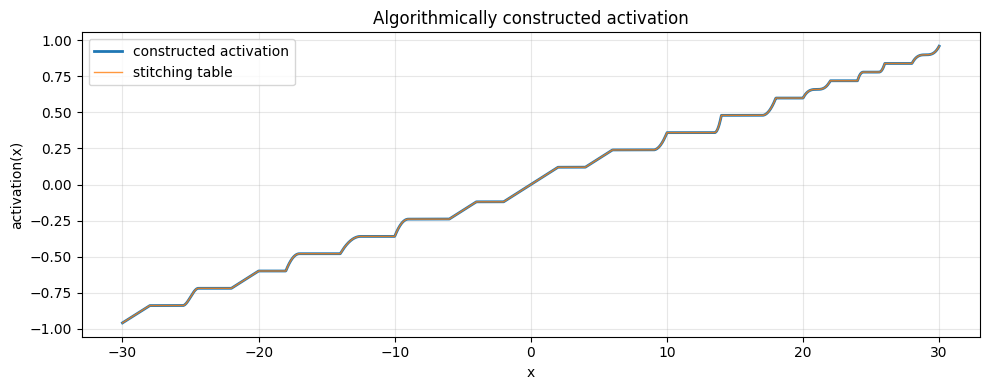

In [3]:
from pathlib import Path
import json

# Export a small downloadable experiment bundle built from the already-constructed activation.
# This keeps the notebook runnable while producing files that can be downloaded and reused.
output_dir = Path("outputs_notebook")
output_dir.mkdir(exist_ok=True)

x_samples = np.linspace(activation.x_table[0], activation.x_table[-1], 2000)
y_samples = activation(x_samples)

np.savetxt(
    output_dir / "activation_samples.csv",
    np.column_stack([x_samples, y_samples]),
    delimiter=",",
    header="x,activation",
    comments="",
)

fig, axis = plt.subplots(figsize=(10, 4))
axis.plot(x_samples, y_samples, label="constructed activation", linewidth=2)
axis.plot(activation.x_table, activation.y_table, label="stitching table", linewidth=1, alpha=0.8)
axis.set_title("Algorithmically constructed activation")
axis.set_xlabel("x")
axis.set_ylabel("activation(x)")
axis.grid(alpha=0.3)
axis.legend()
fig.tight_layout()
fig.savefig(output_dir / "activation_profile.png", dpi=160, bbox_inches="tight")

manifest = {
    "activation_type": "PaperLikeActivation",
    "polynomial_count": activation.polynomial_count,
    "samples_per_interval": activation.samples_per_interval,
    "tail_scale": activation.tail_scale,
    "outputs": [
        "activation_samples.csv",
        "activation_profile.png",
    ],
}
(output_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(f"Exported experiment bundle to {output_dir.resolve()}")
